In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
from utils import (
    select_users_by_period,
    create_hourly_user_dataset,
    compute_position_metrics,
)
from visualization_utils import (
    plot_market_features,
    plot_user_metrics,
)
# from visualization_utils import plot_user_metrics



In [3]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")
# =============================================================================
# HELPER FUNCTIONS (unchanged logic)
# =============================================================================

def add_leverage_factor(df_actions, window_hours=24):
    """
    Add a 'leverage_factor' column to each user's actions.
    Leverage factor = 1 + (number of 'borrow_more_w_collateral' events within window_hours after position_open) // 2
    """
    df = df_actions.sort_values(['user_address', 'timestamp']).copy()
    
    open_times = df[df['event_sequence_type'] == 'position_open'].groupby('user_address')['timestamp'].first().to_dict()
    
    leverage = {}
    for user, open_ts in open_times.items():
        user_df = df[df['user_address'] == user]
        window_end = open_ts + window_hours * 3600
        events = user_df[(user_df['timestamp'] >= open_ts) & (user_df['timestamp'] <= window_end)]
        count = len(events[events['event_sequence_type'] == 'borrow_more_w_collateral'])
        leverage[user] = 1 + count // 2
    
    df['leverage_factor'] = df['user_address'].map(leverage).fillna(1).astype(int)
    return df

def get_users_with_leverage(df_actions, start_date, end_date, window_hours=24, threshold_date=None):
    filtered_actions = select_users_by_period(df_actions, start_date, end_date, threshold_date)
    
    open_events = filtered_actions[filtered_actions['event_sequence_type'] == 'position_open'][['user_address', 'timestamp']].copy()
    open_events = open_events.rename(columns={'timestamp': 'open_time'})
    
    leverage_counts = []
    for user in open_events['user_address'].unique():
        user_open = open_events[open_events['user_address'] == user]['open_time'].iloc[0]
        user_df = filtered_actions[filtered_actions['user_address'] == user]
        
        window_end = user_open + window_hours * 3600
        window_events = user_df[(user_df['timestamp'] >= user_open) & (user_df['timestamp'] <= window_end)]
        
        leverage_count = len(window_events[window_events['event_sequence_type'] == 'borrow_more_w_collateral']) // 2
        leverage_counts.append({'user_address': user, 'leverage_factor': leverage_count})
    
    leverage_df = pd.DataFrame(leverage_counts)
    result = filtered_actions.merge(leverage_df, on='user_address', how='left')
    result["leverage_factor"] += 1

    if threshold_date is not None:
        result = result[result["datetime"].astype(str) < str(threshold_date)]
    
    return result

def add_time_difference_features(hourly_df, lookback_hours=[3, 6], diff_fields=['ltv', 'collateral_price', 'market_utilization', 'borrow_rate']):
    df = hourly_df.sort_values(['user_address', 'timestamp']).copy()
    
    open_times = df.groupby('user_address')['timestamp'].min().reset_index()
    open_times.columns = ['user_address', 'open_timestamp']
    df = df.merge(open_times, on='user_address', how='left')
    
    open_values = df[df['timestamp'] == df['open_timestamp']].copy()
    open_values_dict = {}
    for field in diff_fields:
        open_values_dict[f'open_{field}'] = open_values.set_index('user_address')[field].to_dict()
    
    for field in diff_fields:
        df[f'{field}_vs_open'] = df.apply(
            lambda row: row[field] - open_values_dict[f'open_{field}'].get(row['user_address'], 0), 
            axis=1
        )
    
    for hours in lookback_hours:
        for field in diff_fields:
            df[f'{field}_{hours}h_ago'] = df.groupby('user_address')[field].shift(hours)
            df[f'{field}_vs_{hours}h'] = df[field] - df[f'{field}_{hours}h_ago']
            df = df.drop(columns=[f'{field}_{hours}h_ago'])
    
    df = df.drop(columns=['open_timestamp'])
    return df.fillna(0)

leave_reasons = []
def remove_similar_hours(hourly_df, diff_thresholds, min_events_cnt=5):
    global leave_reasons
    leave_reasons = []
    df = hourly_df.sort_values(['user_address', 'timestamp']).copy()
    result_dfs = []
    
    for user, user_df in df.groupby('user_address'):
        action_mask = user_df['action'] != 'none'
        keep_indices = set(user_df[action_mask].index)
        
        last_kept_idx = None
        
        for idx, curr_row in user_df.iterrows():
            if idx in keep_indices or last_kept_idx is None:
                keep_indices.add(idx)
                last_kept_idx = idx
                continue
            
            prev_row = user_df.loc[last_kept_idx]
            similar = True
            for col, threshold in diff_thresholds.items():
                if col in curr_row and col in prev_row:
                    diff = abs(curr_row[col] - prev_row[col])
                    if diff > threshold:
                        leave_reasons.append(col)
                        similar = False
                        break
            if not similar:
                keep_indices.add(idx)
                last_kept_idx = idx
        
        if len(keep_indices) < min_events_cnt:
            keep_indices = set(user_df[action_mask].index)
        
        if keep_indices:
            result_dfs.append(user_df.loc[list(keep_indices)])
    
    return pd.concat(result_dfs).sort_values(['user_address', 'timestamp'])

def create_model_dataset(hourly_user_df, target_horizon_hours=1, leverage_factor_min=1, liq_threshold=0.86):
    df = hourly_user_df.sort_values(['user_address', 'timestamp']).copy()
    
    if leverage_factor_min > 0:
        df = df[df["leverage_factor"] >= leverage_factor_min]
    
    df["log_debt"] = np.log1p(df["debt"])
    df['has_action'] = (df['action'] != 'none').astype(int)
    
    open_times = df.groupby('user_address')['timestamp'].min().rename('open_timestamp')
    df = df.join(open_times, on='user_address')
    df['days_since_open'] = (df['timestamp'] - df['open_timestamp']) / 3600.0 / 24.0
    
    def compute_hours_since_last_action(group):
        group = group.sort_values('timestamp')
        last_action_ts = None
        res = []
        for ts, action in zip(group['timestamp'], group['has_action']):
            if action == 1:
                res.append(0.0)
                last_action_ts = ts
            else:
                if last_action_ts is None:
                    res.append(1000.0)
                else:
                    res.append((ts - last_action_ts) / 3600.0)
        return pd.Series(res, index=group.index)
    
    df['days_since_last_action'] = df.groupby('user_address', group_keys=False).apply(compute_hours_since_last_action) // 12
    
    def action_count_last_n_hours(group, window_hours=6):
        group = group.sort_values('timestamp')
        timestamps = group['timestamp'].values
        actions = group['has_action'].values
        counts = []
        for i, ts in enumerate(timestamps):
            start = ts - window_hours * 3600
            left = np.searchsorted(timestamps, start, side='left')
            count = np.sum(actions[left:i])
            counts.append(count)
        return pd.Series(counts, index=group.index)
    
    df['action_count_last_6h'] = df.groupby('user_address', group_keys=False).apply(
        lambda g: action_count_last_n_hours(g, 6)
    )
    
    df['ltv_change_1h'] = df.groupby('user_address')['ltv'].diff(1)
    df['distance_to_liq'] = np.maximum(liq_threshold - df['ltv'], 0)
    
    if 'borrow_rate_rolling' in df.columns:
        df['borrow_rate_trend'] = df['borrow_rate'] - df['borrow_rate_rolling']
    else:
        df['borrow_rate_trend'] = df.groupby('user_address')['borrow_rate'].transform(
            lambda x: x - x.rolling(6, min_periods=1).mean()
        )
    
    df['ltv_times_rate'] = df['ltv'] * df['borrow_rate']
    df['debt_change_1h'] = df.groupby('user_address')['debt'].diff(1)
    df['volatility_ltv'] = df['volatility_6h'] * df['ltv']
    df['hour_of_day'] = pd.to_datetime(df['timestamp'], unit='s').dt.hour
    df['day_of_week'] = pd.to_datetime(df['timestamp'], unit='s').dt.dayofweek
    
    def has_action_in_future(group):
        results = []
        timestamps = group['timestamp'].values
        actions = group['has_action'].values
        for i in range(len(group) - 1):
            current_ts = timestamps[i]
            horizon_ts = current_ts + target_horizon_hours * 3600
            future_indices = [j for j in range(i+1, len(group)) if timestamps[j] <= horizon_ts]
            results.append(1 if future_indices and any(actions[future_indices]) else 0)
        results.append(0)
        return pd.Series(results, index=group.index)
    
    df['action_next'] = df.groupby('user_address', group_keys=False).apply(has_action_in_future)
    
    features = [
        "borrow_rate_vs_open",
        "ltv_vs_open",
        "collateral_price_vs_open",
        "collateral_price_vs_6h",
        "volatility_6h",
        "drawdown_6h",
        "hours_since_open",
        "hours_since_last_action",
        "action_count_last_6h",
        "ltv_change_1h",
        "distance_to_liq",
        "borrow_rate_trend",
        "ltv_times_rate",
        "debt_change_1h",
        "volatility_ltv",
        "hour_of_day",
        "day_of_week",
        "log_debt",
    ]
    features = [f for f in features if f in df.columns]
    
    return df[['user_address', 'timestamp'] + features + ['action_next']].fillna(0)

def prepare_features(df):
    df = df.copy()
    categorical_cols = ['hour_of_day', 'day_of_week']
    feature_cols = [col for col in df.columns if col not in ['user_address', 'timestamp', 'action_next']]
    
    for col in categorical_cols:
        if col in feature_cols:
            feature_cols.remove(col)
    
    if 'ltv' in df.columns:
        df['ltv_squared'] = df['ltv'] ** 2
        feature_cols.append('ltv_squared')
    
    if 'ltv' in df.columns and 'hours_since_open' in df.columns:
        df['ltv_time'] = df['ltv'] * df['hours_since_open']
        feature_cols.append('ltv_time')
    
    if 'distance_to_liq' in df.columns:
        df['log_dist_to_liq'] = np.log1p(df['distance_to_liq'])
        feature_cols.append('log_dist_to_liq')
    
    if 'ltv_times_rate' not in feature_cols and 'ltv' in df.columns and 'borrow_rate' in df.columns:
        df['ltv_times_rate'] = df['ltv'] * df['borrow_rate']
        feature_cols.append('ltv_times_rate')
    
    dummies = pd.get_dummies(df[categorical_cols], drop_first=True)
    dummy_names = dummies.columns.tolist()
    
    X = pd.concat([df[feature_cols], dummies], axis=1)
    y = df['action_next'].copy()
    
    feature_names = feature_cols + dummy_names
    return X, y, feature_names, dummy_names

def train_logistic_model_statsmodels(model_df, verbose=True):
    X, y, feature_names, dummy_columns = prepare_features(model_df)
    
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    
    for col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_sm = sm.add_constant(X_train_scaled)
    X_test_sm = sm.add_constant(X_test_scaled)
    model_sm = sm.Logit(y_train, X_train_sm)
    result = model_sm.fit(disp=0, maxiter=1000)
    
    full_feature_names = ['const'] + feature_names
    result.params.index = full_feature_names
    result.bse.index = full_feature_names
    
    y_prob = result.predict(X_test_sm)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    metrics = {'roc_auc': roc_auc, 'pr_auc': pr_auc}
    
    if verbose:
        print("\n=== Model Performance ===")
        print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
        print(f"Action rate in test: {y_test.mean():.3f}")
        print(f"ROC-AUC: {roc_auc:.3f}")
        print(f"PR-AUC: {pr_auc:.3f}")
        
        coef_df = pd.DataFrame({
            'feature': full_feature_names,
            'coefficient': result.params.values,
            'p_value': result.pvalues.values,
            'std_err': result.bse.values
        })
        coef_df['significant'] = coef_df['p_value'] < 0.05
        coef_df['sign'] = ['+' if c > 0 else '-' for c in coef_df['coefficient']]
        coef_df = coef_df.sort_values('p_value')
        
        print("\n=== Feature Significance (sorted by p-value) ===")
        print(coef_df[['feature', 'coefficient', 'p_value', 'significant', 'sign']].to_string(index=False))
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    p_values = pd.Series(result.pvalues.values, index=full_feature_names)
    coefs = pd.Series(result.params.values, index=full_feature_names)
    return result, scaler, p_values, coefs, metrics

def compute_elasticity(model_df, result, scaler, feature_names, features_of_interest):
    X, y, _, _ = prepare_features(model_df)
    X = X[feature_names]
    
    X = X.replace([np.inf, -np.inf], np.nan)
    
    X_scaled = scaler.transform(X)
    X_sm = sm.add_constant(X_scaled)
    
    p = result.predict(X_sm)
    p = p[~np.isnan(p)]
    p_mean = p.mean()
    
    coef_values = result.params.values[1:]  # exclude const
    
    elasticities = {}
    for feat in features_of_interest:
        if feat not in feature_names:
            elasticities[feat] = np.nan
            continue
        
        idx = feature_names.index(feat)
        beta = coef_values[idx]
        x_mean = X[feat].mean()
        elasticity = beta * x_mean * (1 - p_mean)
        elasticities[feat] = elasticity
    
    return elasticities, p_mean

# if __name__ == "__main__":
#     main()

In [4]:
# =============================================================================
# MAIN PIPELINE
# =============================================================================
    # Parameters
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)


def load_data(market_name, events_path, hourly_path):
    """Load events and hourly market data for a given market."""
    df = pd.read_csv(f"{events_path}/{market_name}.csv")
    market_df = pd.read_csv(f"{hourly_path}/{market_name}.csv")
    return df, market_df

def add_yield_to_actions(actions_df, yield_df):
    df = actions_df.copy()
    yield_df = yield_df.copy()
    yield_df['timestamp'] = pd.to_datetime(yield_df['timestamp']).astype('int64') // 10**9
    
    # Get min and max timestamps from yield data
    yield_min = yield_df['timestamp'].min()
    yield_max = yield_df['timestamp'].max()
    
    # Filter actions
    df = df[(df['timestamp'] >= yield_min) & (df['timestamp'] <= yield_max + 30 * 24 * 60 * 60)]
    df = df.sort_values('timestamp')
    yield_df = yield_df.sort_values('timestamp')
    df = pd.merge_asof(
        df,
        yield_df[['timestamp', 'base_apy', 'implied_apy', 'underlying_apy']],
        on='timestamp',
        direction='nearest'
    )
    
    return df

TOKEN = "PT-USDe-25SEP2025"
MARKET = f"eth_{TOKEN}_usdc"
EVENTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_MARKET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
PT_YIELDS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/pt_yields"

# Load data
df, market_df = load_data(MARKET, EVENTS_PATH, HOURLY_MARKET_PATH)
yield_df = pd.read_csv(f"{PT_YIELDS_PATH}/{TOKEN}.csv").sort_values("timestamp")
df = add_yield_to_actions(df, yield_df)
market_df = add_yield_to_actions(market_df, yield_df)

In [5]:
hourly = create_hourly_user_dataset(
    df,
    market_df,
    n_hours=1,
    threshold_date="2025-10-01",
    additional_action_features=["implied_apy"]
)

In [6]:
from datetime import datetime

def parse_expiry_from_token(token_name):
    parts = token_name.split('-')
    for part in parts:
        if len(part) == 9 and part[:2].isdigit() and part[2:5].isalpha() and part[5:].isdigit():
            # format DDMMMYYYY e.g., 25SEP2025
            return datetime.strptime(part, '%d%b%Y')
    return None
def build_position_statistics(df_actions, token_name):
    expiry = parse_expiry_from_token(token_name)
    if expiry is None:
        raise ValueError(f"Cannot parse expiry from token name: {token_name}")
    expiry_ts = expiry.timestamp()
    
    # Get users with at least one position_open
    open_users = df_actions[df_actions['action'] == 'position_open']['user_address'].unique()
    
    results = []
    for user in open_users:
        user_df = df_actions[df_actions['user_address'] == user].sort_values('timestamp')
        
        # Find first open and first close after that
        open_rows = user_df[user_df['action'] == 'position_open']
        if open_rows.empty:
            continue
        open_time = open_rows.iloc[0]['timestamp']
        open_dt = open_rows.iloc[0]['datetime']
        open_ltv = open_rows.iloc[0]['ltv']
        open_debt = open_rows.iloc[0]['debt']
        
        close_rows = user_df[(user_df['action'] == 'position_close') & (user_df['timestamp'] > open_time)]
        if close_rows.empty:
            continue
        close_time = close_rows.iloc[0]['timestamp']
        close_dt = close_rows.iloc[0]['datetime']
        
        # Subset rows between open and close (inclusive)
        position_df = user_df[(user_df['timestamp'] >= open_time) & (user_df['timestamp'] <= close_time)]
        
        max_debt = position_df['debt'].max()
        max_ltv = position_df['ltv'].max()
        min_ltv = position_df[position_df["ltv"] > 0.1]['ltv'].min()
        
        pos_days = (close_time - open_time) / (24 * 3600)
        days_to_expiry = (expiry_ts - close_time) / (24 * 3600)
        
        results.append({
            'user_address': user,
            'opening_date': open_dt,
            'closing_date': close_dt,
            'position_length_days': pos_days,
            'max_debt': max_debt,
            'max_ltv': max_ltv,
            'min_ltv': min_ltv,
            'initial_ltv': open_ltv,
            'initial_debt': open_debt,
            'days_to_expiry_after_close': days_to_expiry
        })
    
    return pd.DataFrame(results)

positions_stats = build_position_statistics(
    hourly,
    token_name=TOKEN,
)

In [7]:
positions_stats["max_ltv"].describe()

count    216.000000
mean       0.807287
std        0.160843
min        0.000399
25%        0.817642
50%        0.864314
75%        0.869776
max        0.913205
Name: max_ltv, dtype: float64

In [8]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

def parse_expiry_from_token(token_name):
    parts = token_name.split('-')
    for part in parts:
        if len(part) == 9 and part[:2].isdigit() and part[2:5].isalpha() and part[5:].isdigit():
            return datetime.strptime(part, '%d%b%Y')
    raise ValueError(f"Cannot parse expiry from {token_name}")

def visualize_position_timeline(df, token_name, market_df=None, col_to_vis='implied_apy'):
    expiry = parse_expiry_from_token(token_name)
    
    df = df.copy()
    df['opening_date'] = pd.to_datetime(df['opening_date'])
    df['closing_date'] = pd.to_datetime(df['closing_date'])
    
    # Daily aggregates for opens
    open_agg = df.groupby(df['opening_date'].dt.date).agg(
        opens=('user_address', 'size'),
        total_debt_opened=('max_debt', 'sum'),
        max_debt_opened=('max_debt', 'max')
    ).reset_index()
    open_agg.columns = ['date', 'opens', 'total_debt_opened', 'max_debt_opened']
    
    # Daily aggregates for closes
    close_agg = df.groupby(df['closing_date'].dt.date).agg(
        closes=('user_address', 'size'),
        total_debt_closed=('max_debt', 'sum'),
        max_debt_closed=('max_debt', 'max')
    ).reset_index()
    close_agg.columns = ['date', 'closes', 'total_debt_closed', 'max_debt_closed']
    
    # Fill missing dates
    all_dates = pd.date_range(df['opening_date'].min(), df['closing_date'].max(), freq='D')
    open_agg = open_agg.set_index('date').reindex(all_dates.date, fill_value=0).reset_index()
    close_agg = close_agg.set_index('date').reindex(all_dates.date, fill_value=0).reset_index()
    open_agg.columns = ['date', 'opens', 'total_debt_opened', 'max_debt_opened']
    close_agg.columns = ['date', 'closes', 'total_debt_closed', 'max_debt_closed']
    
    # Convert to datetime for Plotly
    open_agg['date'] = pd.to_datetime(open_agg['date'])
    close_agg['date'] = pd.to_datetime(close_agg['date'])
    
    # Create figure with secondary_y for row 3 if market_df provided
    if market_df is not None:
        specs = [[{}], [{}], [{"secondary_y": True}]]
    else:
        specs = [[{}], [{}], [{}]]
    
    fig = make_subplots(rows=3, cols=1, shared_xaxes=True, specs=specs,
                        subplot_titles=('Positions Opened per Day', 'Positions Closed per Day', 
                                        'Debt of Positions Opened/Closed per Day'),
                        vertical_spacing=0.1)
    
    # Row 1: Opens count
    fig.add_trace(go.Bar(x=open_agg['date'], y=open_agg['opens'],
                         name='Opened', marker_color='steelblue'),
                  row=1, col=1)
    
    # Row 2: Closes count
    fig.add_trace(go.Bar(x=close_agg['date'], y=close_agg['closes'],
                         name='Closed', marker_color='tomato'),
                  row=2, col=1)
    
    # Row 3: Debt metrics (opened and closed) - primary y-axis
    fig.add_trace(go.Scatter(x=open_agg['date'], y=open_agg['total_debt_opened'],
                             mode='lines+markers', name='Total Debt Opened',
                             line=dict(color='blue', width=2), marker=dict(size=4)),
                  row=3, col=1, secondary_y=False)
    # fig.add_trace(go.Scatter(x=open_agg['date'], y=open_agg['max_debt_opened'],
    #                          mode='lines+markers', name='Max Debt Opened',
    #                          line=dict(color='lightblue', width=2, dash='dot'), marker=dict(size=4)),
    #               row=3, col=1, secondary_y=False)
    fig.add_trace(go.Scatter(x=close_agg['date'], y=close_agg['total_debt_closed'],
                             mode='lines+markers', name='Total Debt Closed',
                             line=dict(color='red', width=2), marker=dict(size=4)),
                  row=3, col=1, secondary_y=False)
    # fig.add_trace(go.Scatter(x=close_agg['date'], y=close_agg['max_debt_closed'],
    #                          mode='lines+markers', name='Max Debt Closed',
    #                          line=dict(color='lightcoral', width=2, dash='dot'), marker=dict(size=4)),
    #               row=3, col=1, secondary_y=False)
    
    # Add implied volatility on secondary y-axis if market_df provided
    if market_df is not None:
        market_df = market_df.copy()
        if 'datetime' not in market_df.columns and 'timestamp' in market_df.columns:
            market_df['datetime'] = pd.to_datetime(market_df['timestamp'], unit='s')
        market_df['date'] = pd.to_datetime(market_df['datetime']).dt.date
        daily_volatility = market_df.groupby('date')[col_to_vis].mean().reset_index()
        daily_volatility['date'] = pd.to_datetime(daily_volatility['date'])
        
        fig.add_trace(go.Scatter(x=daily_volatility['date'], y=daily_volatility[col_to_vis],
                                 mode='lines', name='Mean Implied APY',
                                 line=dict(color='green', width=2, dash='dot')),
                      row=3, col=1, secondary_y=True)
    
    fig.update_layout(height=900, width=1000, title_text=f"Position Activity – {token_name}",
                      showlegend=True)
    fig.update_xaxes(title_text='Date', row=3, col=1)
    fig.update_yaxes(title_text='Number of positions', row=1, col=1)
    fig.update_yaxes(title_text='Number of positions', row=2, col=1)
    fig.update_yaxes(title_text='Debt (USD)', secondary_y=False, row=3, col=1)
    if market_df is not None:
        fig.update_yaxes(title_text='Volatility', secondary_y=True, row=3, col=1)
    
    fig.show()

visualize_position_timeline(
    positions_stats,
    TOKEN,
    market_df
)

In [9]:
positions_stats

,user_address,opening_date,closing_date,position_length_days,max_debt,max_ltv,min_ltv,initial_ltv,initial_debt,days_to_expiry_after_close
0,0x002AFa1e35cE85272aAE5e0d7Ab541DFd442B667,2025-08-19 06:50:11,2025-09-15 21:50:11,27.625000,1.579708e+04,0.852300,0.840134,0.851225,1.579708e+04,8.965150
1,0x016b8816DB87f0a0f8190E3f2ca88357809984A9,2025-09-03 09:42:47,2025-09-25 08:42:47,21.958333,1.679520e+05,0.700039,0.692261,0.699001,1.679520e+05,-0.488044
2,0x019d4248690664e2A87a4AA2a26f83C8E63dE7c4,2025-09-08 04:36:47,2025-09-20 16:36:47,12.500000,6.586510e+06,0.898808,0.866535,0.868874,5.124749e+05,4.182789
3,0x01c2f22754E1C2cc64A18Ba6162E5C7d417ffF7f,2025-08-23 03:35:11,2025-08-23 09:35:11,0.250000,2.499508e+05,0.830221,0.663540,0.663540,1.999606e+05,32.475567
4,0x0297c7990F733B355AaD0e5b4Cf69dD2AbE25F26,2025-09-02 20:52:23,2025-09-25 05:52:23,22.375000,9.921898e+04,0.869537,0.771393,0.869537,5.331045e+04,-0.369711
...,...,...,...,...,...,...,...,...,...,...
211,0xeAbBBF56486A8c92aAb6686c138bA815F91113a6,2025-08-27 17:32:59,2025-09-22 14:32:59,25.875000,1.576236e+04,0.868052,0.462385,0.868052,8.427658e+03,2.268762
212,0xeC378F26231078D9bc3be2ac523651D48dB32892,2025-09-03 08:46:23,2025-09-23 05:46:23,19.875000,4.298770e+03,0.867613,0.845261,0.845261,1.149671e+03,1.634456
213,0xec31Bef615cfCc6ca1d83452599192154D5f8265,2025-09-16 21:39:23,2025-09-25 12:39:23,8.625000,6.123545e+06,0.870238,0.828823,0.869333,1.069941e+06,-0.652350
214,0xf2085a1521D11396FD182C7a5Fb2622f74cf1De6,2025-08-09 08:05:23,2025-09-23 18:05:23,45.416667,6.122648e+07,0.882995,0.512646,0.867085,2.049559e+06,1.121262


In [10]:
import plotly.graph_objects as go
import pandas as pd

def visualize_position_timelines(df, color_by='max_debt', token_name=''):
    """
    Create a Gantt‑style plot of user positions.
    
    Parameters:
    df: DataFrame with columns 'user_address', 'opening_date', 'closing_date', 'position_length_days', and a numeric column for color.
    color_by: column name to use for color mapping (e.g., 'max_debt', 'max_ltv', 'position_length_days').
    token_name: optional token name for title.
    """
    df = df.copy()
    df['opening_date'] = pd.to_datetime(df['opening_date'])
    df['closing_date'] = pd.to_datetime(df['closing_date'])
    
    # Sort by opening date for better visual order
    df = df.sort_values('opening_date')
    # df = df.sort_values('max_ltv')
    
    # Assign a y‑coordinate (row index) for each user
    df['y'] = range(len(df))
    
    # Create figure
    fig = go.Figure()
    
    # For each user, add a horizontal line segment
    for _, row in df.iterrows():
        fig.add_trace(go.Scatter(
            x=[row['opening_date'], row['closing_date']],
            y=[row['y'], row['y']],
            mode='lines+markers',
            line=dict(width=6, color='blue'),
            marker=dict(size=8, color=row[color_by], colorscale='Viridis', 
                       colorbar=dict(title=color_by) if _ == 0 else None),
            name=row['user_address'][:10],
            hoverinfo='text',
            text=f"User: {row['user_address']}<br>Open: {row['opening_date'].date()}<br>Close: {row['closing_date'].date()}<br>{color_by}: {row[color_by]:.2f}<br>max ltv{row['max_ltv']}"
        ))
    
    # Update layout
    fig.update_layout(
        title=f"Position Timelines – {token_name}" if token_name else "Position Timelines",
        xaxis_title="Date",
        yaxis_title="User (sorted by opening date)",
        yaxis=dict(tickmode='array', tickvals=df['y'], ticktext=df['user_address'].str[:12]),
        height=max(600, len(df) * 20),
        hovermode='closest',
        showlegend=False
    )
    print(pd.to_datetime(parse_expiry_from_token(token_name)))
    # fig.add_vline(x=pd.to_datetime(parse_expiry_from_token(token_name)), line_dash='dash', line_color='red', opacity=0.5, annotation_text="Expiry", annotation_position="top")

    
    fig.show()
visualize_position_timelines(positions_stats, color_by='max_debt', token_name='PT-USDe-25SEP2025')


2025-09-25 00:00:00


**all markets**

In [33]:
parse_expiry_from_token

<function __main__.parse_expiry_from_token(token_name)>

In [32]:
ll = []
for fname in os.listdir("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"):
    if not fname.endswith('.csv'):
        continue
    market_name = fname[:-4]  # remove .csv
    # Check if market name starts with "PT-"
    if not market_name.startswith("eth_PT-"):
        continue
    ll.append(market_name)
ll



['eth_PT-syrupUSDC-28AUG2025_usdc',
 'eth_PT-slvlUSD-25SEP2025_usdc',
 'eth_PT-USDe-27NOV2025_usds',
 'eth_PT-USDe-25SEP2025_dai',
 'eth_PT-syrupUSDC-30OCT2025_usdc',
 'eth_PT-USDe-26DEC2024_usdc',
 'eth_PT-stcUSD-23JUL2026_usdc',
 'eth_PT-USDe-27NOV2025_usdc',
 'eth_PT-sNUSD-4JUN2026_usdc',
 'eth_PT-wstUSR-27MAR2025_usr',
 'eth_PT-mHYPER-29JAN2026_usdc',
 'eth_PT-sNUSD-5MAR2026_usdc',
 'eth_PT-lvlUSD-25SEP2025_usdc',
 'eth_PT-USD0++-31OCT2024_usdc',
 'eth_PT-USDe-31JUL2025_dai',
 'eth_PT-USDe-25SEP2025_usdt',
 'eth_PT-USDe-25SEP2025_usdc',
 'eth_PT-USR-4DEC2025_usdc',
 'eth_PT-wstUSR-27MAR2025_usdc',
 'eth_PT-USR-4SEP2025_usdc',
 'eth_PT-slvlUSD-29MAY2025_usdc',
 'eth_PT-mHYPER-20NOV2025_usdc',
 'eth_PT-syrupUSDC-18DEC2025_usdc',
 'eth_PT-sdeUSD-1753142406_usdc',
 'eth_PT-reUSD-25JUN2026_usdc',
 'eth_PT-USD0++-26JUN2025_usdc',
 'eth_PT-reUSD-18DEC2025_usdc',
 'eth_PT-RLP-4SEP2025_usdc',
 'eth_PT-csUSDL-31JUL2025_usdc',
 'eth_PT-mHYPER-30APR2026_usdc',
 'eth_PT-wstUSR-25SEP2025_usdc',


In [12]:
import os
import pandas as pd
from tqdm.auto import tqdm
import re

def parse_expiry_from_token(token_name):
    # Look for pattern: DDMMMYYYY or DMMMYYYY (where D is digit, MMM is month, YYYY is year)
    match = re.search(r'(\d{1,2}[A-Za-z]{3}\d{4})', token_name)
    if match:
        date_str = match.group(1)
        # Pad day to 2 digits if needed
        if len(date_str) == 8:  # DMMMYYYY format
            date_str = '0' + date_str
        return datetime.strptime(date_str, '%d%b%Y')
    raise ValueError(f"Cannot parse expiry from {token_name}")

def collect_position_metrics_for_all_pt_markets(
    events_dir="/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched",
    hourly_dir="/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data",
    yields_dir="/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/pt_yields",
):
    """
    Iterate over all PT-* markets in events_dir, compute position statistics,
    and return a list of dicts with keys: token, market_name, positions_df.
    """
    results = []
    # List all CSV files in events_dir
    for fname in os.listdir(events_dir):
        if not fname.endswith('.csv'):
            continue
        market_name = fname[:-4]  # remove .csv
        # Check if market name starts with "PT-"
        if not market_name.startswith("eth_PT-"):
            continue
        # Extract token name (e.g., PT-USDe-25SEP2025)
        token_name = market_name.split('_')[1]  # assuming format PT-..._usdc
        try:
            expiry = parse_expiry_from_token(token_name)
        except Exception as e:
            continue
        threshold_date = (expiry + pd.Timedelta(days=10)).strftime('%Y-%m-%d')
        # Paths
        events_path = os.path.join(events_dir, fname)
        hourly_path = os.path.join(hourly_dir, f"{market_name}.csv")
        yields_path = os.path.join(yields_dir, f"{token_name}.csv")
        
        # Check if required files exist
        if not os.path.exists(hourly_path):
            print(f"Missing hourly data for {market_name}, skipping")
            continue
        if not os.path.exists(yields_path):
            print(f"Missing yield data for {token_name}, skipping")
            continue
        
        try:
            # Load data
            print(f"Processing market {market_name} (expirity {expiry})... ")
            df = pd.read_csv(events_path)
            market_df = pd.read_csv(hourly_path)
            yield_df = pd.read_csv(yields_path).sort_values("timestamp")
            
            # Add yields to actions
            df = add_yield_to_actions(df, yield_df)
            market_df = add_yield_to_actions(market_df, yield_df)
            
            # Create hourly user dataset
            hourly = create_hourly_user_dataset(
                df,
                market_df,
                n_hours=1,
                threshold_date=threshold_date,
                additional_action_features=["implied_apy"]
            )
            
            # Build position statistics
            pos_stats = build_position_statistics(hourly, token_name)
            
            results.append({
                'token': token_name,
                'market_name': market_name,
                'positions_df': pos_stats,
                'market_df': market_df,
                'raw_df': df,
                'hourly_df': hourly,
            })
            print(f"Processed {market_name}: {len(pos_stats)} positions")
        except Exception as e:
            print(f"Error processing {market_name}: {e}")
            continue
    
    return results

all_markets_position = collect_position_metrics_for_all_pt_markets()

Processing market eth_PT-syrupUSDC-28AUG2025_usdc (expirity 2025-08-28 00:00:00)... 
Processed eth_PT-syrupUSDC-28AUG2025_usdc: 15 positions
Processing market eth_PT-slvlUSD-25SEP2025_usdc (expirity 2025-09-25 00:00:00)... 
Processed eth_PT-slvlUSD-25SEP2025_usdc: 76 positions
Processing market eth_PT-USDe-27NOV2025_usds (expirity 2025-11-27 00:00:00)... 
Processed eth_PT-USDe-27NOV2025_usds: 35 positions
Processing market eth_PT-USDe-25SEP2025_dai (expirity 2025-09-25 00:00:00)... 
Processed eth_PT-USDe-25SEP2025_dai: 128 positions
Processing market eth_PT-syrupUSDC-30OCT2025_usdc (expirity 2025-10-30 00:00:00)... 
Processed eth_PT-syrupUSDC-30OCT2025_usdc: 10 positions
Missing yield data for PT-USDe-26DEC2024, skipping
Processing market eth_PT-stcUSD-23JUL2026_usdc (expirity 2026-07-23 00:00:00)... 
Processed eth_PT-stcUSD-23JUL2026_usdc: 3 positions
Processing market eth_PT-USDe-27NOV2025_usdc (expirity 2025-11-27 00:00:00)... 
Processed eth_PT-USDe-27NOV2025_usdc: 2 positions
Missi

In [14]:
big_markets = []
small_markets = []
for i, r in enumerate(all_markets_position):
    print(i, r["token"], 'Positions cnt', r["positions_df"].shape[0])
    if r["positions_df"].shape[0] > 15:
        big_markets.append(r)
    else:
        small_markets.append(r)
len(big_markets)

0 PT-syrupUSDC-28AUG2025 Positions cnt 15
1 PT-slvlUSD-25SEP2025 Positions cnt 76
2 PT-USDe-27NOV2025 Positions cnt 35
3 PT-USDe-25SEP2025 Positions cnt 128
4 PT-syrupUSDC-30OCT2025 Positions cnt 10
5 PT-stcUSD-23JUL2026 Positions cnt 3
6 PT-USDe-27NOV2025 Positions cnt 2
7 PT-wstUSR-27MAR2025 Positions cnt 51
8 PT-sNUSD-5MAR2026 Positions cnt 6
9 PT-USD0++-31OCT2024 Positions cnt 23
10 PT-USDe-31JUL2025 Positions cnt 95
11 PT-USDe-25SEP2025 Positions cnt 116
12 PT-USDe-25SEP2025 Positions cnt 216
13 PT-wstUSR-27MAR2025 Positions cnt 10
14 PT-slvlUSD-29MAY2025 Positions cnt 35
15 PT-mHYPER-20NOV2025 Positions cnt 77
16 PT-reUSD-25JUN2026 Positions cnt 223
17 PT-reUSD-18DEC2025 Positions cnt 21
18 PT-RLP-4SEP2025 Positions cnt 63
19 PT-csUSDL-31JUL2025 Positions cnt 107
20 PT-wstUSR-25SEP2025 Positions cnt 60
21 PT-stcUSD-29JAN2026 Positions cnt 129
22 PT-lvlUSD-29MAY2025 Positions cnt 85
23 PT-USR-29MAY2025 Positions cnt 18
24 PT-USDe-27MAR2025 Positions cnt 122
25 PT-USD0++-27MAR2025 

20

In [13]:
curr = all_markets_position[index_to_vis]["raw_df"]
curr["market_address"].unique()
curr[curr["ltv_after"] > 0.90]
# curr[curr["user_address"] == "0xc295007e361c22b989F709274a0ff3680BeF0833"]

NameError: name 'index_to_vis' is not defined

In [ ]:
index_to_vis = 18

visualize_position_timeline(
    all_markets_position[index_to_vis]["positions_df"],
    all_markets_position[index_to_vis]["token"],
    market_df=all_markets_position[index_to_vis]["market_df"],
    col_to_vis='collateral_price'
)

In [ ]:
all_markets_position[0]#['positions_df']
len(big_markets)
big_markets[0]
print(big_markets[10]['market_name'])
big_markets[10]["positions_df"]
big_markets[10]['raw_df']['market_address'].unique()

eth_PT-stcUSD-29JAN2026_usdc


array(['0x03f715ef1ae508ab3e1faf4dffdbf2a077d1f0ad10c5aad42cf4438d5e3328af'],
      dtype=object)

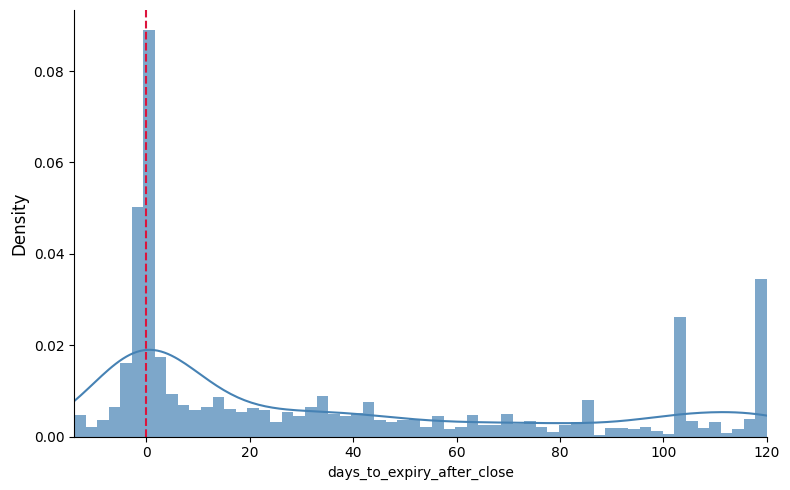

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_expiry_aggregate(market_info_list, x_range=(-14, 120), bins=60):
    all_data = []
    for info in market_info_list:
        df = info['positions_df']
        if df.empty or 'days_to_expiry_after_close' not in df.columns:
            continue
        all_data.append(df['days_to_expiry_after_close'].dropna())
    if not all_data:
        print("No data")
        return
    combined = pd.concat(all_data, ignore_index=True)
    clipped = combined.clip(lower=x_range[0], upper=x_range[1])

    plt.figure(figsize=(8, 5))
    sns.histplot(clipped, bins=bins, stat='density', kde=True,
                 color='steelblue', edgecolor=None, alpha=0.7)
    plt.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5)
    plt.xlim(x_range)
    # plt.xlabel('Days relative to expiry (negative = closed after expiry)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Использование
plot_expiry_aggregate(big_markets)


### **Display what was happening on markets when poss were closed**

In [23]:
# all_markets_position[0]['positions_df']

In [26]:
# all_markets_position[0]['positions_df']['closing_date']
# rw = all_markets_position[0]['raw_df']
# openers = []
# suppliers_shares = 
# addrs = all_markets_position[0]['raw_df']['user_address']


import pandas as pd
from datetime import datetime
import re

def parse_expiry_from_token(token_name):
    """Extract expiry date from token name like 'PT-syrupUSDC-28AUG2025'."""
    match = re.search(r'(\d{1,2}[A-Za-z]{3}\d{4})', token_name)
    if match:
        date_str = match.group(1)
        if len(date_str) == 8:
            date_str = '0' + date_str
        return datetime.strptime(date_str, '%d%b%Y')
    return None

def get_base_token(token_name):
    """Extract base token without expiry, e.g., 'PT-syrupUSDC-28AUG2025' -> 'PT-syrupUSDC'."""
    # Remove the last part after last '-' (the expiry date)
    parts = token_name.split('-')
    # Keep all parts except the last one (the expiry)
    return '-'.join(parts[:-1])

def analyze_cross_expiry_positions(market_dicts):
    """
    market_dicts: list of dicts with keys 'token', 'market_name', 'positions_df'
    Returns: dict with base_token -> DataFrame of users with positions in multiple markets.
    """
    # Group by base token
    base_token_dict = {}
    for m in market_dicts:
        token = m['token']
        base = get_base_token(token)
        expiry = parse_expiry_from_token(token)
        if base not in base_token_dict:
            base_token_dict[base] = []
        base_token_dict[base].append({
            'token': token,
            'expiry': expiry,
            'market_name': m['market_name'],
            'positions_df': m['positions_df'].copy()
        })
    
    results = {}
    for base, markets in base_token_dict.items():
        # Sort markets by expiry (earliest first)
        markets.sort(key=lambda x: x['expiry'])
        # For each user, collect positions across markets
        user_positions = {}
        for m in markets:
            df = m['positions_df']
            for _, row in df.iterrows():
                user = row['user_address']
                if user not in user_positions:
                    user_positions[user] = []
                user_positions[user].append({
                    'expiry': m['expiry'],
                    'market_name': m['market_name'],
                    'opening_date': row['opening_date'],
                    'closing_date': row['closing_date'],
                    'max_debt': row['max_debt'],
                    'position_length_days': row['position_length_days'],
                    'days_to_expiry_after_close': row['days_to_expiry_after_close'],
                })
        # Keep only users with positions in more than one market
        multi_market_users = {u: pos for u, pos in user_positions.items() if len(pos) > 1}
        if multi_market_users:
            # Create a DataFrame for easier printing
            records = []
            for user, positions in multi_market_users.items():
                for pos in positions:
                    records.append({
                        'user_address': user,
                        'expiry': pos['expiry'],
                        'market_name': pos['market_name'],
                        'opening_date': pos['opening_date'],
                        'closing_date': pos['closing_date'],
                        'max_debt': pos['max_debt'],
                        'position_length_days': pos['position_length_days'],
                        'days_to_expiry_after_close': pos['days_to_expiry_after_close'],
                    })
            results[base] = pd.DataFrame(records).sort_values(['user_address', 'expiry'])
    
    return results

dd = analyze_cross_expiry_positions(all_markets_position)
for base, df in dd.items():
    print(f"\nBase token: {base}")
    df['user_max_debt'] = df.groupby('user_address')['max_debt'].transform('max')

    # Sort by user_max_debt descending, then by expiry
    df_sorted = df.sort_values(['user_max_debt', 'expiry'], ascending=[False, True])

    # Drop the helper column
    df_sorted = df_sorted.drop(columns=['user_max_debt'])

    # Print
    print(df_sorted.to_string(index=False))




Base token: PT-slvlUSD
                              user_address     expiry                   market_name        opening_date        closing_date     max_debt  position_length_days  days_to_expiry_after_close
0xC28e8f073439800dF7A4934d198E1966B4Dd8A25 2025-05-29 eth_PT-slvlUSD-29MAY2025_usdc 2025-04-08 07:03:59 2025-05-29 07:03:59 6.397240e+06             51.000000                   -0.419433
0xC28e8f073439800dF7A4934d198E1966B4Dd8A25 2025-09-25 eth_PT-slvlUSD-25SEP2025_usdc 2025-05-29 06:38:47 2025-07-21 03:38:47 1.019801e+06             52.875000                   65.723067
0xFbbF1826Aba90704A2167D2EB4A7a9D83A8DE9c7 2025-05-29 eth_PT-slvlUSD-29MAY2025_usdc 2025-04-22 17:16:23 2025-05-29 21:16:23 6.395783e+06             37.166667                   -1.011377
0xFbbF1826Aba90704A2167D2EB4A7a9D83A8DE9c7 2025-09-25 eth_PT-slvlUSD-25SEP2025_usdc 2025-05-21 20:47:47 2025-07-19 23:47:47 1.137468e+06             59.125000                   66.883484
0x37829FE9b8e67B8267C2058b9459f524b9E3ca5

In [27]:
all_markets_position[0]
for i in range(len(all_markets_position)):
    if all_markets_position[i]['market_name'] in ('eth_PT-USDe-25SEP2025_dai', 'eth_PT-USDe-25SEP2025_usdc', 'eth_PT-USDe-25SEP2025_usdt'):
        print(i, all_markets_position[i]['market_name'])

3 eth_PT-USDe-25SEP2025_dai
11 eth_PT-USDe-25SEP2025_usdt
12 eth_PT-USDe-25SEP2025_usdc


In [30]:
# 0xCCeE77e74C4466DF0dA0ec85F2D3505956fD6Fa7
plot_market_features(all_markets_position[3]['market_df'], fields=['borrow_rate', 'borrow_rate'])
plot_market_features(all_markets_position[11]['market_df'], fields=['borrow_rate', 'borrow_rate'])
plot_market_features(all_markets_position[12]['market_df'], fields=['borrow_rate', 'borrow_rate'])


In [49]:
import plotly.graph_objects as go
import pandas as pd

def plot_position_timelines(df, color_by='max_debt', token_name=''):
    """
    Create a Gantt‑style plot of user positions.

    Parameters:
    df: DataFrame with columns 'user_address', 'opening_date', 'closing_date', and a numeric column for color.
    color_by: column name to use for color mapping (e.g., 'max_debt', 'max_ltv', 'position_length_days').
    token_name: optional token name for title.
    """
    df = df.copy()
    df['opening_date'] = pd.to_datetime(df['opening_date'])
    df['closing_date'] = pd.to_datetime(df['closing_date'])
    
    # Sort by opening date for better visual order
    df = df.sort_values('opening_date')
    
    # Assign a y‑coordinate (row index) for each user
    df['y'] = range(len(df))
    df['y'] = np.arange(0, len(df) * 0.2, 0.2)   # 0.5 spacing

    
    # Create figure
    fig = go.Figure()
    
    # For each user, add a horizontal line segment
    for _, row in df.iterrows():
        fig.add_trace(go.Scatter(
            x=[row['opening_date'], row['closing_date']],
            y=[row['y'], row['y']],
            mode='lines+markers',
            line=dict(width=8, color='blue'),
            marker=dict(size=8, color=row[color_by], colorscale='Viridis',
                       colorbar=dict(title=color_by) if _ == 0 else None),
            name=row['user_address'][:10],
            hoverinfo='text',
            text=f"User: {row['user_address']}<br>Open: {row['opening_date'].date()}<br>Close: {row['closing_date'].date()}<br>{color_by}: {row[color_by]:.2f}"
        ))
        # fig.add_vline(x=pd.to_datetime('2025-01-01'), line_dash='dash', line_color='red', opacity=0.7, annotation_text="Cutoff", annotation_position="top")

    
    # Update layout
    fig.update_layout(
        title=f"Position Timelines – {token_name}" if token_name else "Position Timelines",
        xaxis_title="Date",
        yaxis_title="User (sorted by opening date)",
        yaxis=dict(tickmode='array', tickvals=df['y'], ticktext=df['user_address'].str[:12]),
        height=max(600, len(df) * 20),
        hovermode='closest',
        showlegend=False
    )
    
    fig.show()

plot_position_timelines(all_markets_position[0]['positions_df'])

In [45]:
pd.to_datetime('2025-01-01')

Timestamp('2025-01-01 00:00:00')

In [51]:
for market_data in all_markets_position[:100]:
    print("MARKET", market_data['market_name'])
    closing_dates = market_data['positions_df']['closing_date'].astype(str).str[:10]
    opening_dates = market_data['positions_df']['opening_date'].astype(str).str[:10]
    market_data['market_df']['closing_cnt'] = market_data['market_df'].apply(lambda r : (closing_dates == str(r['datetime'])[:10]).sum(), axis=1)
    market_data['market_df']['opening_cnt'] = market_data['market_df'].apply(lambda r : (opening_dates == str(r['datetime'])[:10]).sum(), axis=1)

    print(market_data['market_df']['closing_cnt'].value_counts())
    # plot_market_features(
    #     market_data['market_df'],
    #     ['implied_apy', 'opening_cnt'],
    #     y_ranges={'utilization': [0.5, 1], 'borrow_rate': [0, 0.3], 'implied_apy': [0, 0.2]}
    # )
    # plot_position_timelines(market_data['positions_df'])

MARKET eth_PT-syrupUSDC-28AUG2025_usdc
closing_cnt
0    2927
1     312
2      24
Name: count, dtype: int64
MARKET eth_PT-slvlUSD-25SEP2025_usdc
closing_cnt
0     3098
1      672
2      192
3       48
16      24
6       24
4       24
Name: count, dtype: int64
MARKET eth_PT-USDe-27NOV2025_usds
closing_cnt
0     2502
1      312
5       48
10      24
2       24
Name: count, dtype: int64
MARKET eth_PT-USDe-25SEP2025_dai
closing_cnt
0     2337
1      264
2      144
3       72
5       48
4       48
6       24
8       24
11      24
16      24
37      24
Name: count, dtype: int64
MARKET eth_PT-syrupUSDC-30OCT2025_usdc
closing_cnt
0    2287
1     240
Name: count, dtype: int64
MARKET eth_PT-stcUSD-23JUL2026_usdc
closing_cnt
0    1085
1      72
Name: count, dtype: int64
MARKET eth_PT-wstUSR-27MAR2025_usr
closing_cnt
0     1305
1      264
2       72
4       48
26      24
Name: count, dtype: int64
MARKET eth_PT-sNUSD-5MAR2026_usdc
closing_cnt
0    631
1     96
2     24
Name: count, dtype: int64
MARK

                        N       Mean     Median        Std  \
Market                                                       
PT-slvlUSD-25SEP2025   76  35.361212  21.714456  40.865161   
PT-USDe-25SEP2025     128   4.817838   0.943067   9.122852   
PT-wstUSR-27MAR2025    51   2.482762  -0.195544   6.676271   
PT-USDe-31JUL2025      95  52.117513  62.769873  42.221590   
PT-USDe-25SEP2025     116  16.007963   5.659456  19.732205   
PT-USDe-25SEP2025     216  11.551052   2.270706  17.105739   
PT-mHYPER-20NOV2025    77  17.150738  15.143345  18.182105   
PT-csUSDL-31JUL2025   107  10.433919  -0.562488  23.323081   
PT-wstUSR-25SEP2025    60  55.122361  48.682928  48.230060   
PT-lvlUSD-29MAY2025    85   4.703404  -0.288461  11.878803   
PT-USDe-27MAR2025     122  35.947372  30.529387  37.478635   

                      % Closed Before Expiry (>0)  % Closed ≤30d Before  \
Market                                                                    
PT-slvlUSD-25SEP2025                    53.

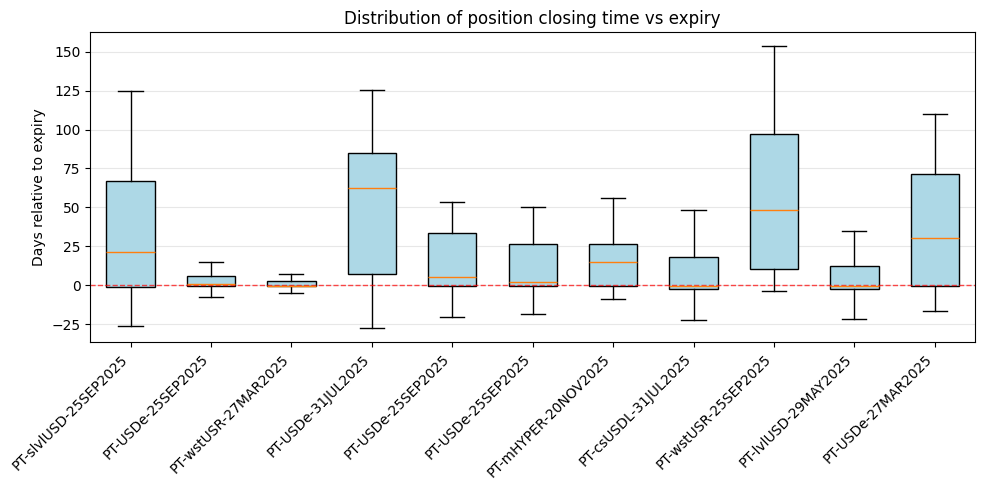

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def expiry_summary_table(market_info_list):
    """
    Returns a DataFrame with key statistics of days_to_expiry_after_close per market.
    Columns: count, mean, median, std, %_closed_before_expiry, %_closed_after_expiry,
             %_within_30d_before, %_within_7d_before
    """
    rows = []
    for info in market_info_list:
        df = info['positions_df']
        token = info['token']
        if '2026' in token:
            continue
        if df.empty or 'days_to_expiry_after_close' not in df.columns:
            continue
        data = df['days_to_expiry_after_close'].dropna()
        if len(data) == 0:
            continue

        closed_before = (data > 7).mean() * 100
        closed_after  = (data <= 7).mean() * 100
        within_30 = ((data > 0) & (data <= 30)).mean() * 100
        within_7  = ((data > 0) & (data <= 7)).mean() * 100

        rows.append({
            'Market': token,
            'N': len(data),
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            '% Closed Before Expiry (>0)': closed_before,
            '% Closed ≤30d Before': within_30,
            '% Closed ≤7d Before': within_7,
            '% Closed After Expiry (<0)': closed_after
        })
    return pd.DataFrame(rows).set_index('Market')

def print_latex_table(summary_df, caption="Closing time relative to expiry", label="tab:expiry"):
    """Print a LaTeX-formatted table for the summary DataFrame."""
    latex = summary_df.round(2).to_latex(
        caption=caption,
        label=label,
        position='htbp',
        na_rep='--'
    )
    print(latex)

def plot_expiry_boxplot(market_info_list, figsize=(10, 5), showfliers=False):
    """
    Clean boxplot showing distribution of days_to_expiry_after_close per market.
    If showfliers=False, outliers are hidden (can make the plot cleaner).
    """
    all_data = []
    labels = []
    for info in market_info_list:
        df = info['positions_df']
        token = info['token']
        if '2026' in token:
            continue
        if df.empty or 'days_to_expiry_after_close' not in df.columns:
            continue
        data = df['days_to_expiry_after_close'].dropna()
        if len(data) == 0:
            continue
        all_data.append(data)
        labels.append(token)

    plt.figure(figsize=figsize)
    bp = plt.boxplot(all_data, labels=labels, showfliers=showfliers, 
                     patch_artist=True, widths=0.6)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.ylabel('Days relative to expiry')
    plt.title('Distribution of position closing time vs expiry')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

# ==================== USAGE EXAMPLE ====================
if __name__ == "__main__":
    # market_info_list = [{'token': 'USDT', 'positions_df': df1}, ...]
    # ...
    summary = expiry_summary_table(big_markets)
    print(summary)
    # print_latex_table(summary)  # for paper

    plot_expiry_boxplot(big_markets, showfliers=False)

In [29]:
def aggregate_expiry_latex(market_info_list, label='tab:expiry_aggregate', 
                           caption='Aggregated closing time relative to expiry'):
    all_data = []
    for info in market_info_list:
        df = info['positions_df']
        if df.empty or 'days_to_expiry_after_close' not in df.columns:
            continue
        all_data.append(df['days_to_expiry_after_close'].dropna())
    if not all_data:
        return ""
    d = pd.concat(all_data, ignore_index=True)
    N = len(d)
    mean_val = d.mean()
    # Compute fractions
    closed_before = (d > 0).mean()
    closed_ge30   = (d >= 30).mean()
    closed_0_7    = ((d >= 0) & (d < 7)).mean()
    closed_7_30   = ((d >= 7) & (d < 30)).mean()
    closed_after  = (d < 0).mean()

    table = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
\\begin{{tabular}}{{lc}}
\\toprule
Metric & Value \\\\
\\midrule
Total positions (N) & {N:,} \\\\
Mean days to expiry (all positions) & {mean_val:.2f} \\\\
\\addlinespace
\\multicolumn{{2}}{{l}}{{\\textbf{{Distribution of closing times}}}} \\\\
\\;\\; \\% Closed $\\ge 30$ days before expiry & {closed_ge30*100:.1f}\\% \\\\
\\;\\; \\% Closed $7$–$30$ days before expiry & {closed_7_30*100:.1f}\\% \\\\
\\;\\; \\% Closed $0$–$7$ days before expiry & {closed_0_7*100:.1f}\\% \\\\
\\;\\; \\% Closed after expiry & {closed_after*100:.1f}\\% \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    print(table)

# Использование:
aggregate_expiry_latex(big_markets)



\begin{table}[htbp]
\centering
\caption{Aggregated closing time relative to expiry}
\label{tab:expiry_aggregate}
\begin{tabular}{lc}
\toprule
Metric & Value \\
\midrule
Total positions (N) & 1,485 \\
Mean days to expiry (all positions) & 38.23 \\
\addlinespace
\multicolumn{2}{l}{\textbf{Distribution of closing times}} \\
\;\; \% Closed $\ge 30$ days before expiry & 43.1\% \\
\;\; \% Closed $7$–$30$ days before expiry & 13.2\% \\
\;\; \% Closed $0$–$7$ days before expiry & 12.9\% \\
\;\; \% Closed after expiry & 30.8\% \\
\bottomrule
\end{tabular}
\end{table}



In [68]:
plot_market_features(
    big_markets[5]["market_df"],
    ["borrow_rate", "total_borrow"]
)

eth_PT-syrupUSDC-28AUG2025_usdc
eth_PT-USDe-27NOV2025_usds
eth_PT-syrupUSDC-30OCT2025_usdc
eth_PT-stcUSD-23JUL2026_usdc
eth_PT-sNUSD-5MAR2026_usdc
eth_PT-wstUSR-27MAR2025_usdc
eth_PT-slvlUSD-29MAY2025_usdc
eth_PT-reUSD-18DEC2025_usdc
eth_PT-USR-29MAY2025_usdc


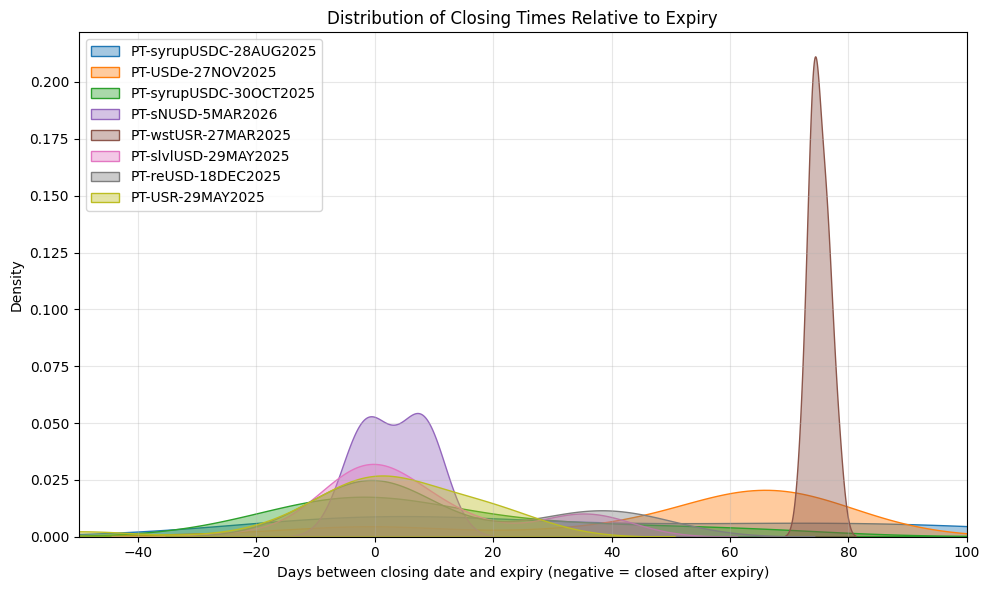

In [60]:
plot_expiry_distributions(small_markets)


In [67]:
small_markets[1]['positions_df']

,user_address,opening_date,closing_date,position_length_days,max_debt,max_ltv,min_ltv,initial_ltv,initial_debt,days_to_expiry_after_close
0,0x008E5d9ea233Dfb9AB48098d6E98E14374030c15,2025-09-11 15:22:11,2025-11-27 05:22:11,76.583333,9.846727e+05,0.857051,0.820956,0.856001,1.689294e+05,-0.348738
1,0x051Ef87C542Ec5cA717AA19210B2657598a57319,2025-09-13 13:45:23,2025-10-04 10:45:23,20.875000,3.978531e+07,0.857598,0.799883,0.000000,0.000000e+00,53.426817
2,0x0c5772B86d2715485f18ef5B1ADCddc809A468B8,2025-09-11 11:58:11,2025-09-18 08:58:11,6.875000,7.657741e+04,0.858369,0.846400,0.857155,7.657741e+04,69.501262
3,0x0fb93047Af51923993cBB9C7547b1354a4fBa9b6,2025-09-21 14:14:59,2025-09-25 06:14:59,3.666667,7.998672e+02,0.800333,0.798209,0.800108,7.998672e+02,62.614595
4,0x14FAa112a14b70328D2cA17102aAfE398F0c369c,2025-09-12 04:42:11,2025-09-27 03:42:11,14.958333,1.483549e+06,0.898071,0.891306,0.897528,1.042683e+06,60.720706
5,0x16f037a3dDf53dA1b047A926E1833219F0a8E1FC,2025-09-10 01:31:11,2025-09-25 06:31:11,15.208333,3.835535e+06,0.858269,0.852435,0.858269,1.023449e+03,62.603345
6,0x1be45feF92C4E2538fEcd150757Ed62b7B3757D7,2025-09-13 17:43:11,2025-09-18 14:43:11,4.875000,1.563149e+07,0.100745,0.100141,0.031136,4.834315e+06,69.261678
7,0x1fc75ad0511DDC3A23B9583BA1C285b8292FAEd5,2025-09-16 16:57:59,2025-09-25 03:57:59,8.458333,3.499013e+06,0.711949,0.608429,0.608429,2.998536e+06,62.709734
8,0x21C9cE0611541099583E4249bfB583606715a796,2025-09-16 11:13:11,2025-09-25 13:13:11,9.083333,6.546922e+05,0.891553,0.882183,0.882183,6.497023e+05,62.324178
9,0x21F1359b6DD3392d3DC567d005d83B6d017CC60D,2025-09-12 16:43:47,2025-09-19 08:43:47,6.666667,2.081178e+05,0.867566,0.861779,0.867566,2.081178e+05,68.511262


In [65]:
plot_market_features(
    small_markets[1]["market_df"],
    ["borrow_rate", "total_borrow"]
)

**Who close the position early?**

PT-USDe-25SEP2025


((84, 10), (216, 10))

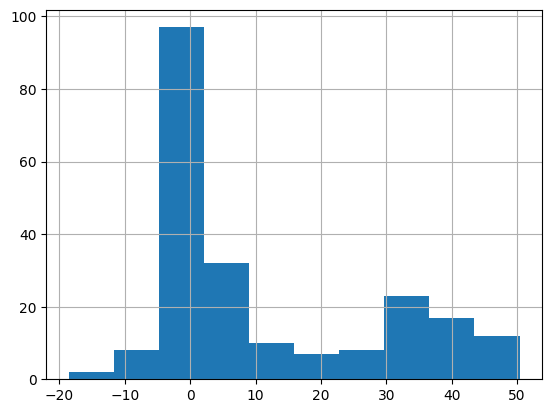

In [91]:
market_index = 5
print(big_markets[market_index]["token"])
positions_df = big_markets[market_index]["positions_df"]
positions_df["days_to_expiry_after_close"].hist()
early_thr = 7
early_closing = positions_df[positions_df["days_to_expiry_after_close"] >= early_thr]
late_closing = positions_df[positions_df["days_to_expiry_after_close"] < early_thr]

early_closing_raw_df = big_markets[market_index]["raw_df"]
early_closing_raw_df = early_closing_raw_df[early_closing_raw_df["user_address"].isin(early_closing["user_address"].unique())]
late_closing_raw_df = big_markets[market_index]["raw_df"]
late_closing_raw_df = late_closing_raw_df[late_closing_raw_df["user_address"].isin(late_closing["user_address"].unique())]

early_closing_raw_df = add_leverage_factor(early_closing_raw_df)
late_closing_raw_df = add_leverage_factor(late_closing_raw_df)

early_closing.shape, positions_df.shape

<Axes: >

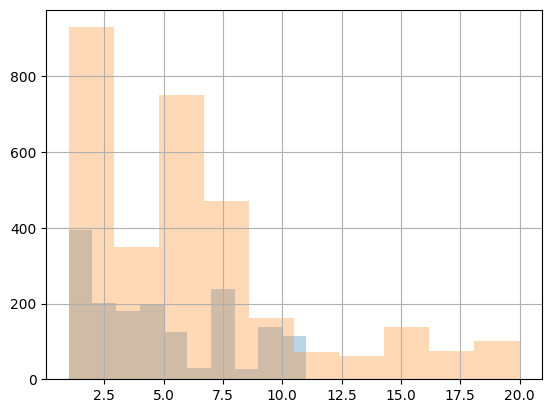

In [92]:
early_closing_raw_df["leverage_factor"].hist(alpha=0.3)
late_closing_raw_df["leverage_factor"].hist(alpha=0.3)

<Axes: >

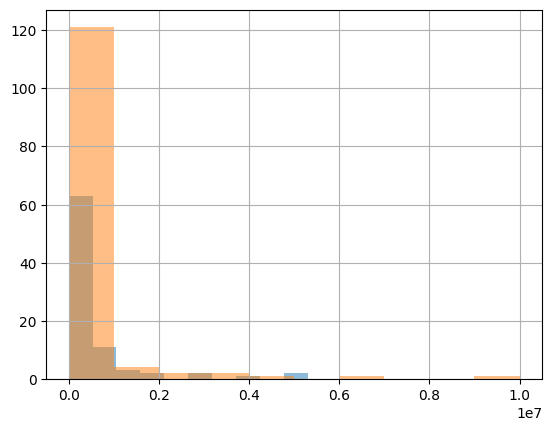

In [93]:
# early_closing["initial_ltv"].hist()
# late_closing["initial_ltv"].hist()

early_closing["initial_debt"].hist(alpha=0.5)
late_closing["initial_debt"].hist(alpha=0.5)


<Axes: >

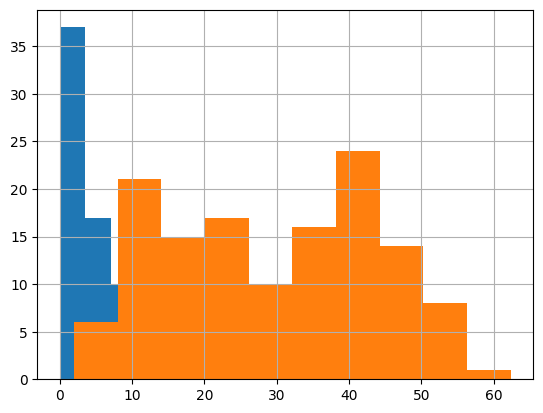

In [94]:
early_closing["position_length_days"].hist()
late_closing["position_length_days"].hist()

In [95]:
# for i in late_closing.sort_values("max_debt", ascending=False)["user_address"].unique()[:20]:
#     plot_user_metrics(
#         big_markets[market_index]["hourly_df"],
#         ['debt', 'implied_apy'],
#         i,
#         # dates_range=("2025-01-01", "2025-10-25"),
#     )

In [96]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

def parse_expiry_from_token(token_name):
    import re
    from datetime import datetime
    match = re.search(r'(\d{1,2}[A-Za-z]{3}\d{4})', token_name)
    if match:
        date_str = match.group(1)
        if len(date_str) == 8:
            date_str = '0' + date_str
        return datetime.strptime(date_str, '%d%b%Y')
    raise ValueError(f"Cannot parse expiry from {token_name}")

def add_leverage_factor(df_actions, window_hours=24):
    df = df_actions.sort_values(['user_address', 'timestamp']).copy()
    open_times = df[df['event_sequence_type'] == 'position_open'].groupby('user_address')['timestamp'].first().to_dict()
    leverage = {}
    for user, open_ts in open_times.items():
        user_df = df[df['user_address'] == user]
        window_end = open_ts + window_hours * 3600
        events = user_df[(user_df['timestamp'] >= open_ts) & (user_df['timestamp'] <= window_end)]
        count = len(events[events['event_sequence_type'] == 'borrow_more_w_collateral'])
        leverage[user] = 1 + count // 2
    df['leverage_factor'] = df['user_address'].map(leverage).fillna(1).astype(int)
    return df

def prepare_user_features(market_info, early_threshold=7):
    token = market_info['token']
    positions_df = market_info['positions_df']
    raw_df = market_info['raw_df']
    market_df = market_info['market_df']
    expiry_date = parse_expiry_from_token(token)
    expiry_ts = expiry_date.timestamp()
    raw_df = add_leverage_factor(raw_df)
    features_list = []
    for idx, row in positions_df.iterrows():
        user = row['user_address']
        open_time = row['opening_date'].timestamp()
        initial_ltv = row['initial_ltv']
        initial_debt = row['initial_debt']
        user_leverage = raw_df[raw_df['user_address'] == user]['leverage_factor'].iloc[0] if len(raw_df[raw_df['user_address'] == user]) > 0 else 1
        days_to_expiry_open = (expiry_ts - open_time) / (24*3600)
        market_row = market_df.iloc[(market_df['timestamp'] - open_time).abs().argsort()[:1]]
        vol = market_row['volatility_6h'].values[0] if not market_row.empty else 0
        borrow_rate = market_row['borrow_rate'].values[0] if not market_row.empty else 0
        implied_apy = market_row['implied_apy'].values[0] if not market_row.empty else 0
        target = 1 if row['days_to_expiry_after_close'] >= early_threshold else 0
        features_list.append({
            'user': user,
            'initial_ltv': initial_ltv,
            'initial_debt': np.log1p(initial_debt),
            'leverage_factor': user_leverage,
            'days_to_expiry_open': days_to_expiry_open,
            'volatility_6h': vol,
            'borrow_rate': borrow_rate,
            'target': target,
            'implied_apy': 'implied_apy',
        })
    return pd.DataFrame(features_list)

def train_early_closing_classifier(market_info_list, early_threshold=7, model_type='xgb'):
    all_data = []
    for info in market_info_list:
        if info["token"] == "PT-reUSD-25JUN2026":
            continue
        df_feat = prepare_user_features(info, early_threshold)
        all_data.append(df_feat)
    combined = pd.concat(all_data, ignore_index=True).dropna()
    X = combined.drop(['user', 'target'], axis=1)
    y = combined['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    if model_type == 'lr':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        model = LogisticRegression(class_weight='balanced', max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        model = xgb.XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        scaler = None
    
    print("=== OVERALL CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred))
    print(f"Overall ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
    
    print("\n=== PER MARKET METRICS (TEST SET ONLY) ===")
    test_users = X_test.index if hasattr(X_test, 'index') else range(len(X_test))
    for info in market_info_list:
        token = info['token']
        df_feat = prepare_user_features(info, early_threshold)
        if df_feat.empty:
            print(f"{token}: No data")
            continue
        
        # Get test indices for this market
        test_mask = df_feat.index.isin(test_users)
        X_market = df_feat.drop(['user', 'target'], axis=1)
        y_market = df_feat['target']
        
        X_market_test = X_market[test_mask]
        y_market_test = y_market[test_mask]
        
        if X_market_test.empty:
            print(f"{token}: No test samples")
            continue
        
        if model_type == 'lr':
            X_market_scaled = scaler.transform(X_market_test)
            y_pred_market = model.predict(X_market_scaled)
            y_prob_market = model.predict_proba(X_market_scaled)[:,1]
        else:
            y_pred_market = model.predict(X_market_test)
            y_prob_market = model.predict_proba(X_market_test)[:,1]
        
        from sklearn.metrics import precision_score, recall_score
        prec = precision_score(y_market_test, y_pred_market, zero_division=0)
        rec = recall_score(y_market_test, y_pred_market, zero_division=0)
        try:
            auc = roc_auc_score(y_market_test, y_prob_market)
        except Exception as e:
            auc=0
        print(f"{token}: N_test={len(y_market_test)}, Class1_test={(y_market_test==1).sum()}, Precision={prec:.3f}, Recall={rec:.3f}, ROC-AUC={auc:.3f}")
    
    return model, scaler, combined


model, scaler, feature_df = train_early_closing_classifier(
    market_info_list=big_markets,
    early_threshold=7,
    model_type='xgb'  # or 'lr' for logistic regression
)

# To see feature importance for XGBoost
if hasattr(model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': ['initial_ltv', 'log_initial_debt', 'leverage_factor', 'days_to_expiry_open', 'volatility_6h', 'borrow_rate', 'implied_apy'],
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    print(importance_df)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:implied_apy: object

In [ ]:
for i in big_markets:
    print(i["positions_df"].shape)

(76, 10)
(128, 10)
(51, 10)
(95, 10)
(116, 10)
(216, 10)
(77, 10)
(223, 10)
(107, 10)
(60, 10)
(129, 10)
(85, 10)
(122, 10)
